In [5]:
import pandas as pd

df = pd.read_csv("../data/synthetic_fooddelivery_dataset.csv")
df.head()

,ID_Pesanan,Waktu_Transaksi,Kategori_Menu,Harga_Pesanan,Jarak_Kirim_KM,Waktu_Tunggu_Menit,Rating_Pelanggan,Ulasan_Teks,Status_Promo,Tingkat_Keluhan,Status_Pesanan
0,ORD-2024-000001,2024-03-22 13:15:14,Kopi,9000,NaN,27,4.0,Sesuai pesanan,False,Tidak Ada,Selesai
1,ORD-2024-000002,2024-01-14 17:05:37,Mie,21000,3.742238,37,NaN,NaN,False,Tidak Ada,Selesai
2,ORD-2024-000003,2024-01-04 12:32:38,Martabak,33500,12.677149,49,NaN,NaN,True,Rendah,Selesai
3,ORD-2024-000004,2024-01-26 22:34:26,Kopi,13500,2.338085,20,5.0,Mantap gan!,False,Tidak Ada,Selesai
4,ORD-2024-000005,2024-03-16 11:48:51,Ayam,47500,0.949764,27,4.0,Top bgt kualitasnya,True,Rendah,Selesai


In [6]:
df.shape

(8500, 11)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID_Pesanan          8500 non-null   object 
 1   Waktu_Transaksi     8500 non-null   object 
 2   Kategori_Menu       8500 non-null   object 
 3   Harga_Pesanan       8500 non-null   int64  
 4   Jarak_Kirim_KM      7905 non-null   float64
 5   Waktu_Tunggu_Menit  8500 non-null   int64  
 6   Rating_Pelanggan    6800 non-null   float64
 7   Ulasan_Teks         6800 non-null   object 
 8   Status_Promo        8500 non-null   bool   
 9   Tingkat_Keluhan     8500 non-null   object 
 10  Status_Pesanan      8500 non-null   object 
dtypes: bool(1), float64(2), int64(2), object(6)
memory usage: 672.5+ KB


In [8]:
df.head()

,ID_Pesanan,Waktu_Transaksi,Kategori_Menu,Harga_Pesanan,Jarak_Kirim_KM,Waktu_Tunggu_Menit,Rating_Pelanggan,Ulasan_Teks,Status_Promo,Tingkat_Keluhan,Status_Pesanan
0,ORD-2024-000001,2024-03-22 13:15:14,Kopi,9000,NaN,27,4.0,Sesuai pesanan,False,Tidak Ada,Selesai
1,ORD-2024-000002,2024-01-14 17:05:37,Mie,21000,3.742238,37,NaN,NaN,False,Tidak Ada,Selesai
2,ORD-2024-000003,2024-01-04 12:32:38,Martabak,33500,12.677149,49,NaN,NaN,True,Rendah,Selesai
3,ORD-2024-000004,2024-01-26 22:34:26,Kopi,13500,2.338085,20,5.0,Mantap gan!,False,Tidak Ada,Selesai
4,ORD-2024-000005,2024-03-16 11:48:51,Ayam,47500,0.949764,27,4.0,Top bgt kualitasnya,True,Rendah,Selesai


Understanding Each Column

In [9]:
df['Waktu_Transaksi'].value_counts()

Waktu_Transaksi
04/03/2024 14:18       2
20/02/2024 11:56       2
2024-01-03 11:01:50    2
14/03/2024 17:23       2
24/02/2024 11:11       2
                      ..
01/02/2024 11:56       1
03/03/2024 21:18       1
2024-02-19 14:25:38    1
2024-01-02 12:55:21    1
2024-03-13 11:48:00    1
Name: count, Length: 8481, dtype: int64

In [10]:
df['Waktu_Transaksi'].describe()

count                 8500
unique                8481
top       04/03/2024 14:18
freq                     2
Name: Waktu_Transaksi, dtype: object

In [19]:
df.isnull().sum()

ID_Pesanan               0
Waktu_Transaksi          0
Kategori_Menu            0
Harga_Pesanan            0
Jarak_Kirim_KM         595
Waktu_Tunggu_Menit       0
Rating_Pelanggan      1700
Ulasan_Teks           1700
Status_Promo             0
Tingkat_Keluhan          0
Status_Pesanan           0
dtype: int64

In [23]:
df['Rating_Pelanggan'] = df.groupby('Kategori_Menu')['Rating_Pelanggan'].transform(lambda x: x.fillna(x.median()))

In [24]:
df['Rating_Pelanggan'].isnull().sum()

np.int64(0)

In [28]:

df['Jarak_Kirim_KM'] = df.groupby('Kategori_Menu')['Jarak_Kirim_KM'].transform(lambda x: x.fillna(x.median()))

In [30]:
df['Ulasan_Teks'] = df['Ulasan_Teks'].fillna('No Review')

In [31]:
df.isnull().sum()

ID_Pesanan            0
Waktu_Transaksi       0
Kategori_Menu         0
Harga_Pesanan         0
Jarak_Kirim_KM        0
Waktu_Tunggu_Menit    0
Rating_Pelanggan      0
Ulasan_Teks           0
Status_Promo          0
Tingkat_Keluhan       0
Status_Pesanan        0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(0)

Order Distribution by Menu Category

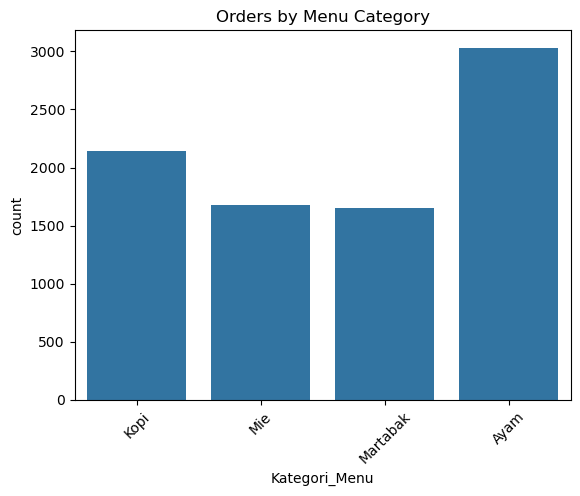

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Kategori_Menu', data=df)
plt.title("Orders by Menu Category")
plt.xticks(rotation=45)
plt.show()

Insight:

Ayam is the most popular menu category with the highest number of orders,
indicating strong customer preference for chicken-based meals.
Kopi ranks second, suggesting beverages are also frequently ordered.

Mie and Martabak have relatively similar and lower order volumes compared
to Ayam, indicating moderate demand.

Business Insight:

The restaurant should prioritize maintaining supply and availability of
Ayam dishes because they drive the largest portion of orders.

Promotions could be used to increase demand for Mie and Martabak to balance
menu popularity.

Rating Distribution

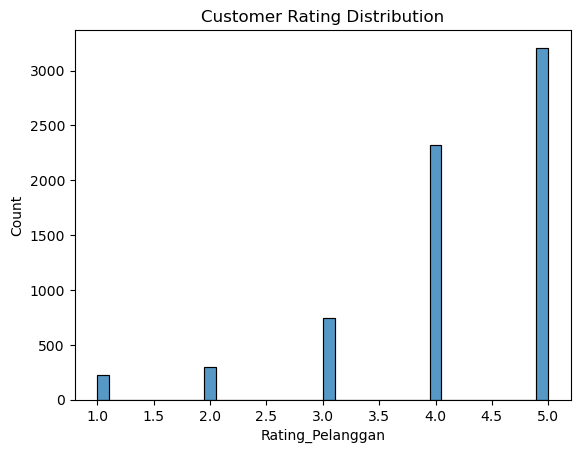

In [12]:
sns.histplot(df['Rating_Pelanggan'])
plt.title("Customer Rating Distribution")
plt.show()

Differentiate by Category

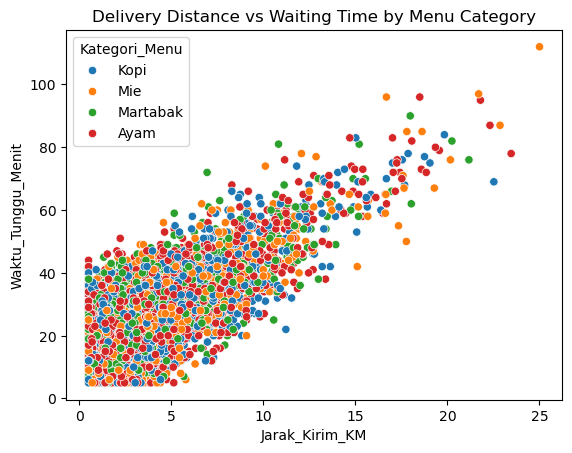

In [13]:
sns.scatterplot(
    x='Jarak_Kirim_KM',
    y='Waktu_Tunggu_Menit',
    hue='Kategori_Menu',
    data=df
)

plt.title("Delivery Distance vs Waiting Time by Menu Category")
plt.show()

Observation:
There is a clear positive relationship between delivery distance and waiting time.
Orders that travel longer distances generally take more time to be delivered.

Differentiate by Complaint Level

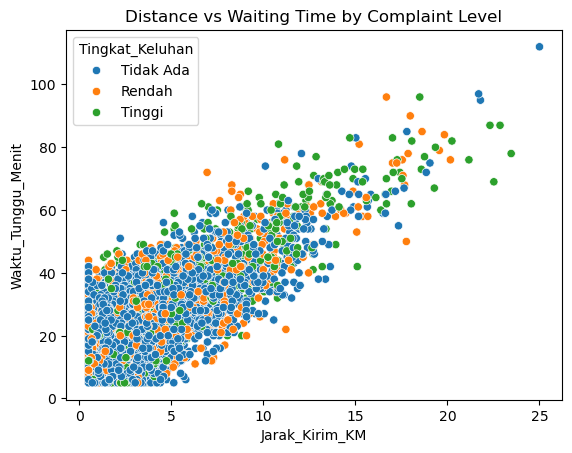

In [14]:
sns.scatterplot(
    x='Jarak_Kirim_KM',
    y='Waktu_Tunggu_Menit',
    hue='Tingkat_Keluhan',
    data=df
)

plt.title("Distance vs Waiting Time by Complaint Level")
plt.show()

Differentiate by Promotion

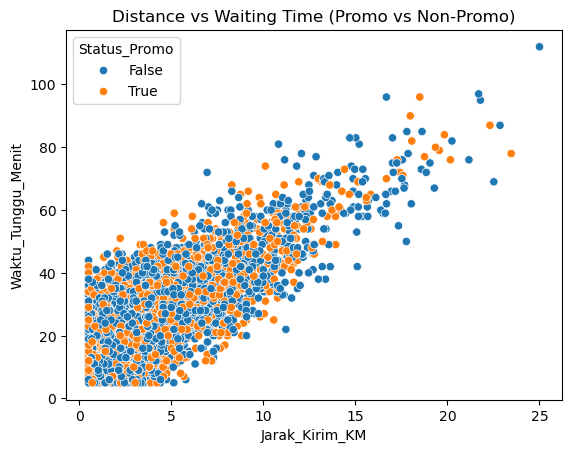

In [15]:
sns.scatterplot(
    x='Jarak_Kirim_KM',
    y='Waktu_Tunggu_Menit',
    hue='Status_Promo',
    data=df
)

plt.title("Distance vs Waiting Time (Promo vs Non-Promo)")
plt.show()

Trend Line

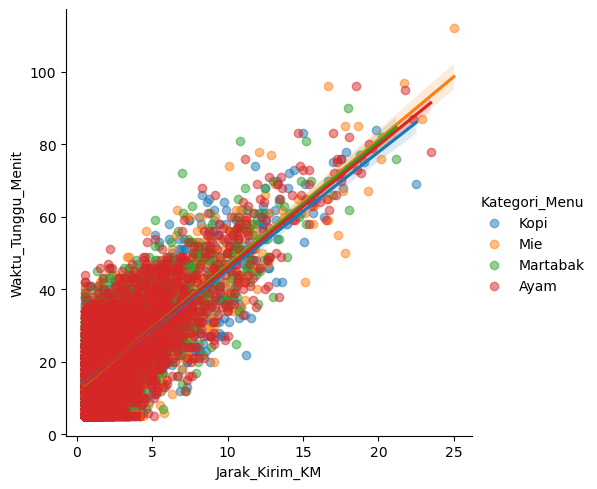

In [16]:
sns.lmplot(
    x='Jarak_Kirim_KM',
    y='Waktu_Tunggu_Menit',
    data=df,
    hue='Kategori_Menu',
    scatter_kws={'alpha': 0.5}
)

In [17]:
df.groupby('Kategori_Menu')['Waktu_Tunggu_Menit'].mean()

Kategori_Menu
Ayam        22.428383
Kopi        22.709482
Martabak    22.666869
Mie         23.194527
Name: Waktu_Tunggu_Menit, dtype: float64

Average waiting time by menu category shows only small differences between
food types, confirming that preparation time does not significantly affect
delivery duration.

Preparing the Data before creating the dashboard with the

Use of clean dataset, Exporting it from Python

In [33]:
df.to_csv("food_delivery_clean.csv", index=False)